# TITULO

## 1. Introduccion 

### 1.1 Contexto

### 1.2 Objetivo

## 2. Carga e Inspeccion Inicial

### 2.1 Importacion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from IPython.display import display

### 2.2 Carga del Dataset

In [2]:
# Cargamos un diccionario con las traducciones de los codigos de preguntas
with open("data/traducciones.json", "r") as file:
    traducciones = json.load(file)
    traducciones_df = pd.DataFrame(traducciones.items())

# Cargamos el dataset con los datos
df = pd.read_csv("data/EMSE_DatosAbiertos.csv")

### 2.3 Informacion General

In [3]:
df.shape

(56981, 309)

In [4]:
df.isna().sum()

sitio              0
record             0
q1               108
texto_q1         108
q2               536
                ... 
qnpe5g          1949
texto_qnpe5g       0
weight             0
stratum            0
psu                0
Length: 309, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Columns: 309 entries, sitio to psu
dtypes: float64(154), int64(3), object(152)
memory usage: 134.3+ MB


Observamos que el dataset cuenta con 56981 filas y 309 columnas o features.

In [6]:
df.head()

,sitio,record,q1,texto_q1,q2,texto_q2,q3,texto_q3,q4,q5,...,texto_qnpa5g,qnpa7g,texto_qnpa7g,qnpe3g,texto_qnpe3g,qnpe5g,texto_qnpe5g,weight,stratum,psu
0,AG,1,3.0,13 aÃ±os,2.0,Femenino,2.0,9no grado nivel Primario/Polimodal o 2do aÃ±o ...,NaN,NaN,...,Si,1.0,Si,2.0,No,2.0,No,457.09,201801010,19
1,AG,2,3.0,13 aÃ±os,2.0,Femenino,2.0,9no grado nivel Primario/Polimodal o 2do aÃ±o ...,NaN,NaN,...,Si,2.0,No,2.0,No,2.0,No,457.09,201801010,19
2,AG,3,4.0,14 aÃ±os,1.0,Masculino,4.0,2do aÃ±o/11vo grado nivel Polimodal o 4to aÃ±o...,1.67,56.0,...,Si,2.0,No,2.0,No,2.0,No,261.44,201801010,19
3,AG,4,6.0,16 aÃ±os,1.0,Masculino,2.0,9no grado nivel Primario/Polimodal o 2do aÃ±o ...,1.73,70.0,...,No,2.0,No,1.0,Si,1.0,Si,550.90,201801010,19
4,AG,5,3.0,13 aÃ±os,2.0,Femenino,2.0,9no grado nivel Primario/Polimodal o 2do aÃ±o ...,NaN,NaN,...,No,2.0,No,2.0,No,2.0,No,457.09,201801010,19


## 3. Comprension de Variables

Se puede observar que el dataset cuenta con 2 columnas para cada pregunta del cuestionario, una numerica y una codificada en texto. Todas las respuestas a las preguntas son de tipo **categorica** y tienen asociado su correspondiente lista de codigos validos presentes en la documentacion.

In [7]:
# Obtenemos todas las columnas que comiencen con "q", 
# aquellas que representan un pregunta del cuestionario.
# Evitamos las columnas que representan la misma pregunta pero con
# su respuesta en formato textual.
df[df.columns[pd.Series(df.columns).str.startswith('q')]].columns

Index(['q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q10', 'q15', 'q16', 'q17',
       ...
       'qnff2g', 'qnff3g', 'qntob2g', 'qnnotb2g', 'qnbcanyg', 'qnc1g',
       'qnpa5g', 'qnpa7g', 'qnpe3g', 'qnpe5g'],
      dtype='object', length=153)

Observamos entonces que el cuestionario cuenta con 153 preguntas.

## 4. Preseleccion de Variables

Para simplificar el analisis vamos a hacer una preseleccion de las variables que consideramos, a grandes razgos, que podrian estar relacionadas al objetivo final.

In [8]:
from matplotlib.ticker import PercentFormatter
from textwrap import fill

def get_colors(n):
    return plt.cm.tab20(np.arange(n))

def print_question(q, figsize=(12, 5)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    fig.suptitle(f"{q}: {traducciones.get(q, q)}")

    series = df[q]
    labels = df[[q, "texto_" + q]].drop_duplicates().sort_values(by=q)["texto_" + q].dropna()
    labels = [fill(label, width=24) for label in labels]

    # --- Plot 1: Value frequencies as percentages ---
    value_pct = (
        series.value_counts(dropna=True, normalize=True)
        .sort_index()
        .mul(100)
    )
    
    colors = get_colors(len(value_pct))
    max_pct = value_pct.max()

    value_pct.plot(kind="bar", ax=ax1, color=colors)
    ax1.set_title("Distribucion de Respuestas")
    ax1.set_ylabel("Frecuencia (%)")
    ax1.set_xlabel("Respuesta")
    ax1.set_ylim(0, max(100, max_pct * 1.15))
    ax1.yaxis.set_major_formatter(PercentFormatter())
    ax1.set_xticklabels(
        labels[:len(value_pct)],
        rotation=45,
        ha="right"
    )

    # Add labels on bars
    for container in ax1.containers:
        ax1.bar_label(container, fmt="%.1f%%")

    # --- Plot 2: NaN vs Non-NaN percentages ---
    nan_pct = series.isna().mean() * 100
    non_nan_pct = 100 - nan_pct
    max_pct = max(nan_pct, non_nan_pct)

    ax2.barh(
        ["No nulos", "Nulos"],
        [non_nan_pct, nan_pct],
        color=colors
    )
    ax2.set_title("Respuestas Nulas")
    ax2.set_xlabel("Frecuencia (%)")
    ax2.xaxis.set_major_formatter(PercentFormatter())
    ax2.set_xlim(0, max(100, max_pct * 1.15))

    # Add labels on bars
    for container in ax2.containers:
        ax2.bar_label(container, fmt="%.1f%%")

    plt.tight_layout()
    plt.show()

### 4.1 Definicion del Target

El objetivo de este trabajo es preparar los datos para predecir si un estudiante presenta **tendencia suicida**. La variable target se define como una derivacion de las features **q25** y **q26**.

In [9]:
print("q25:", traducciones["q25"])

display(df[["q25", "texto_q25"]].sort_values(by="q25").drop_duplicates())

print("q26:", traducciones["q26"])
display(df[["q26", "texto_q26"]].sort_values(by="q26").drop_duplicates())

q25: Durante los últimos 12 meses, ¿hiciste algún plan de cómo intentarías suicidarte?


,q25,texto_q25
18392,1.0,Si
38774,2.0,No
184,NaN,Dato perdido


q26: Durante los últimos 12 meses, ¿cuántas veces intentaste realmente suicidarte?


,q26,texto_q26
0,1.0,0 veces
27900,2.0,1 vez
2247,3.0,2 o 3 veces
670,4.0,4 o 5 veces
52410,5.0,6 o mÃ¡s veces
86,NaN,Dato perdido


Ambas features son categoricas: *q25* es binaria y *q26* es ordinal.

Se considera que un estudiante presenta **tendencia suicida** si cumple al menos una de estas condiciones en los ultimos 12 meses:
1. hizo algun plan de como suicidarse, o
2. intento suicidarse al menos una vez.

La variable target se define entonces como:

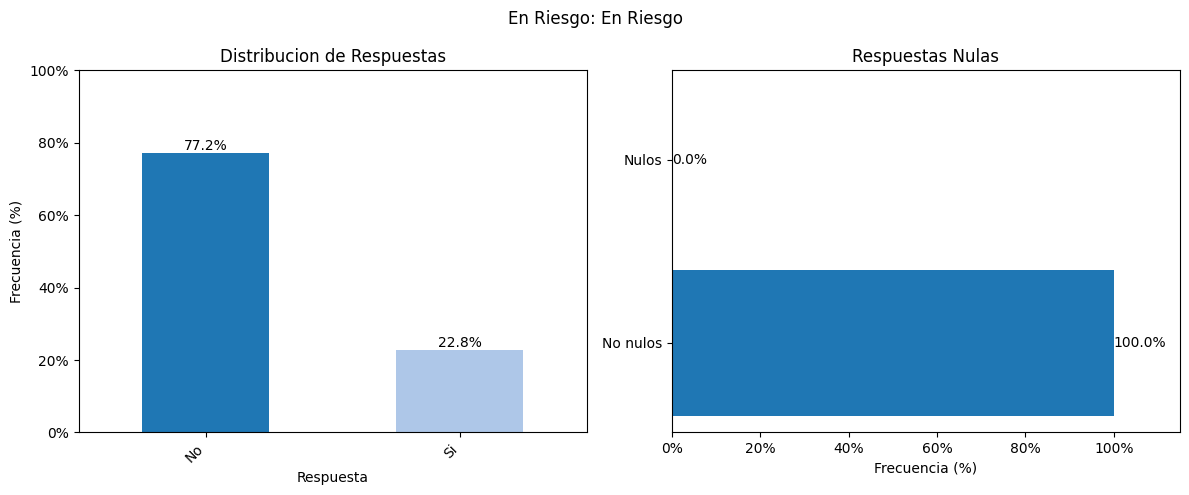

In [10]:
target = "En Riesgo"
df[target] = np.where((df["q25"] == 1) | (df["q26"] >= 2), 1, 0)
df["texto_" + target] = np.where(df[target] == 1, "Si", "No")

print_question(target)

### 4.2 Variables Demograficas

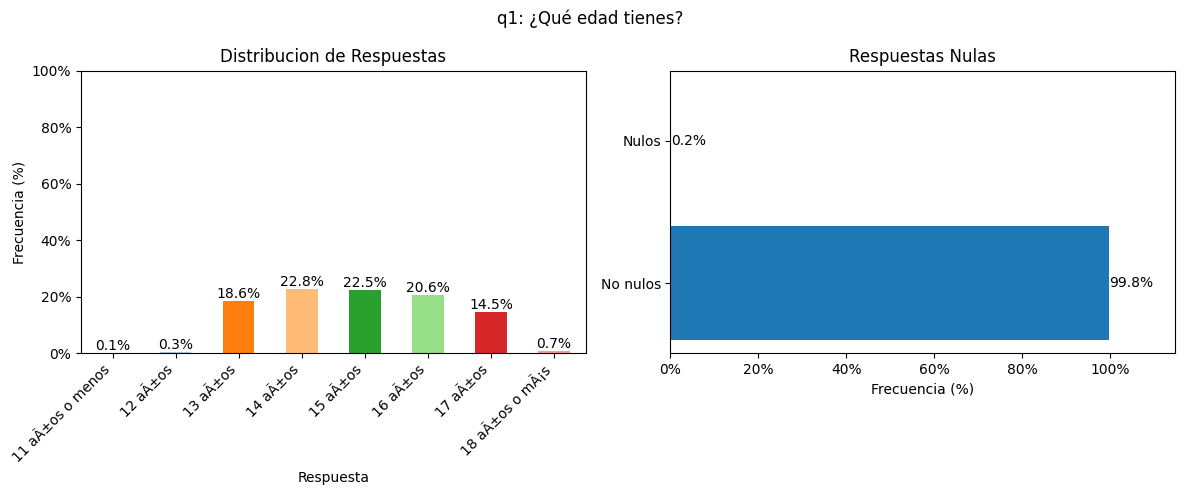

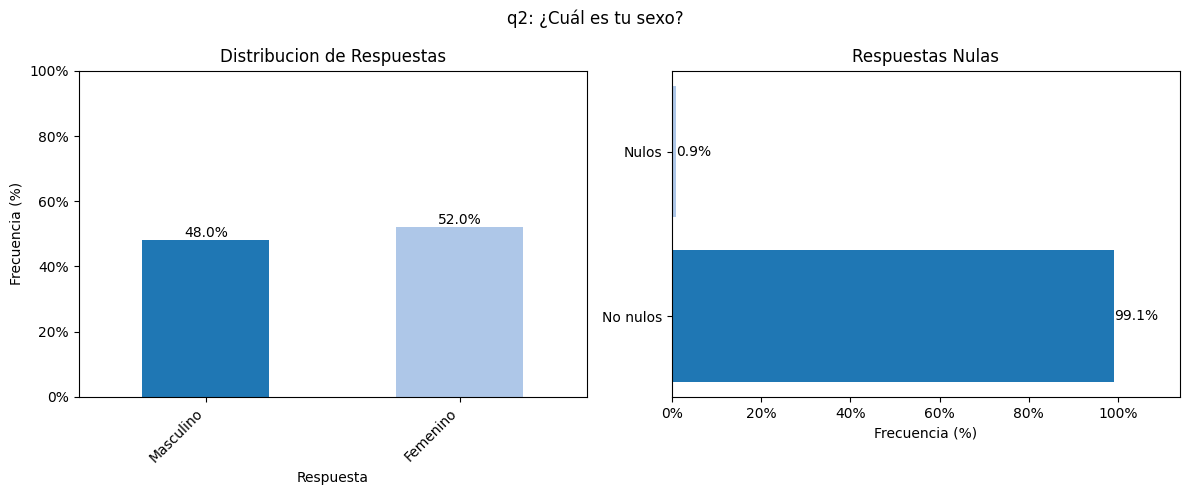

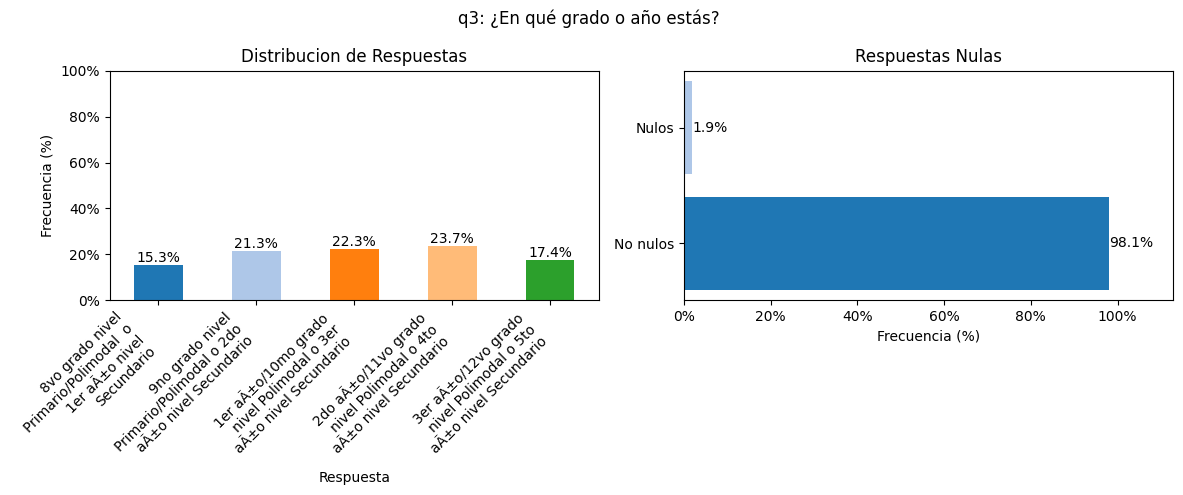

In [11]:
demograficas = ["q1", "q2", "q3"]

for q in demograficas:
    print_question(q)

### 4.3 Variables de Salud Mental

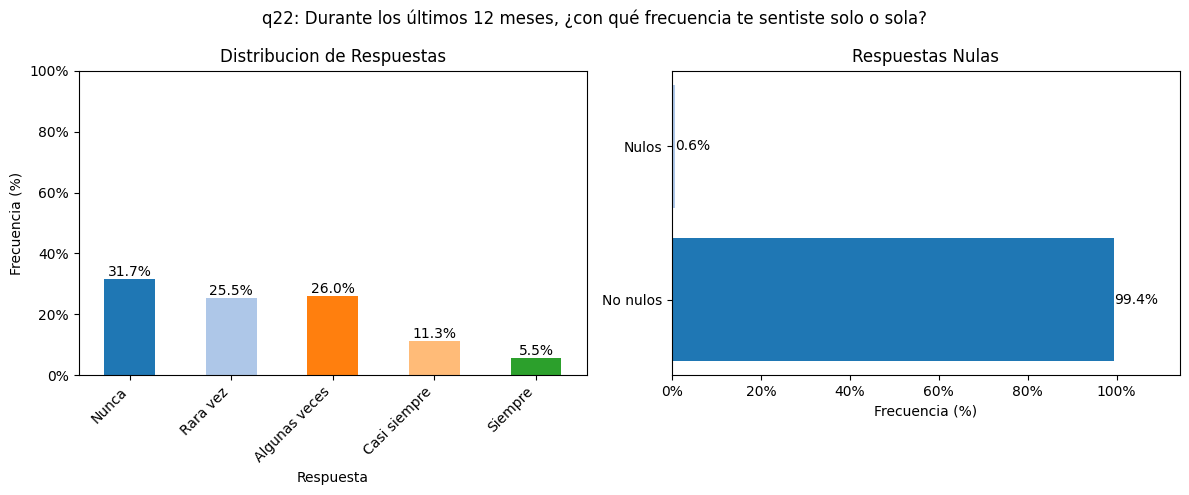

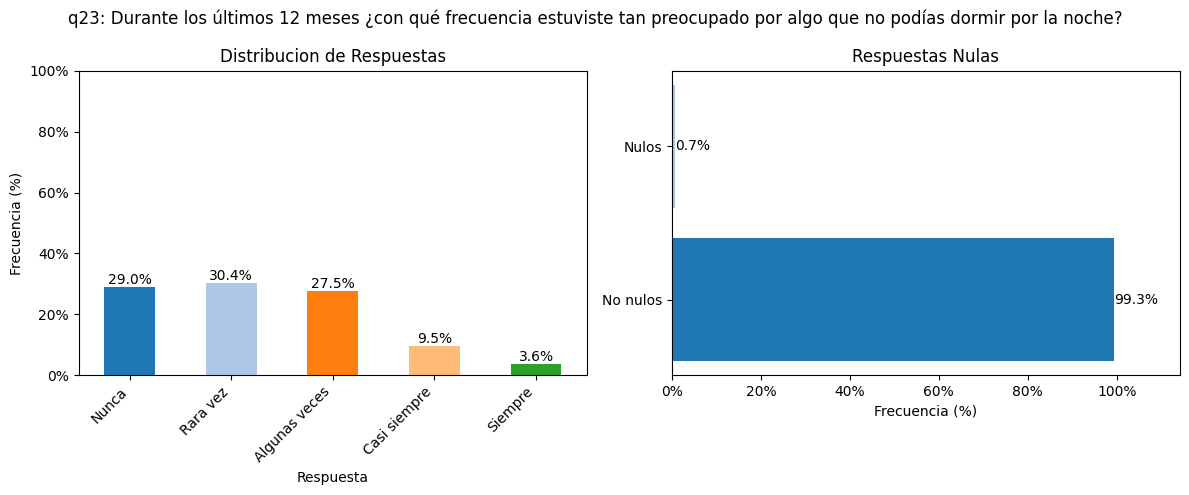

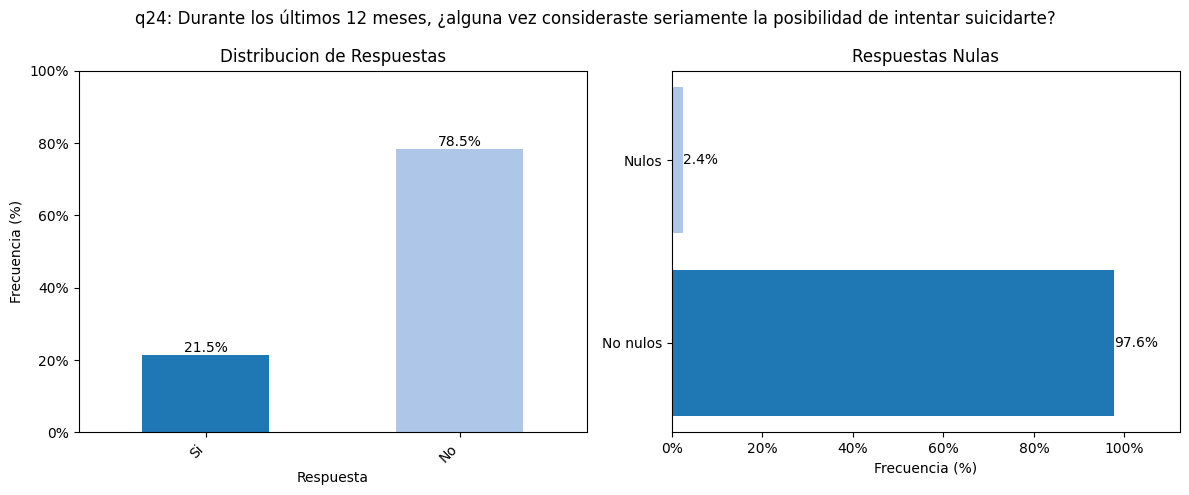

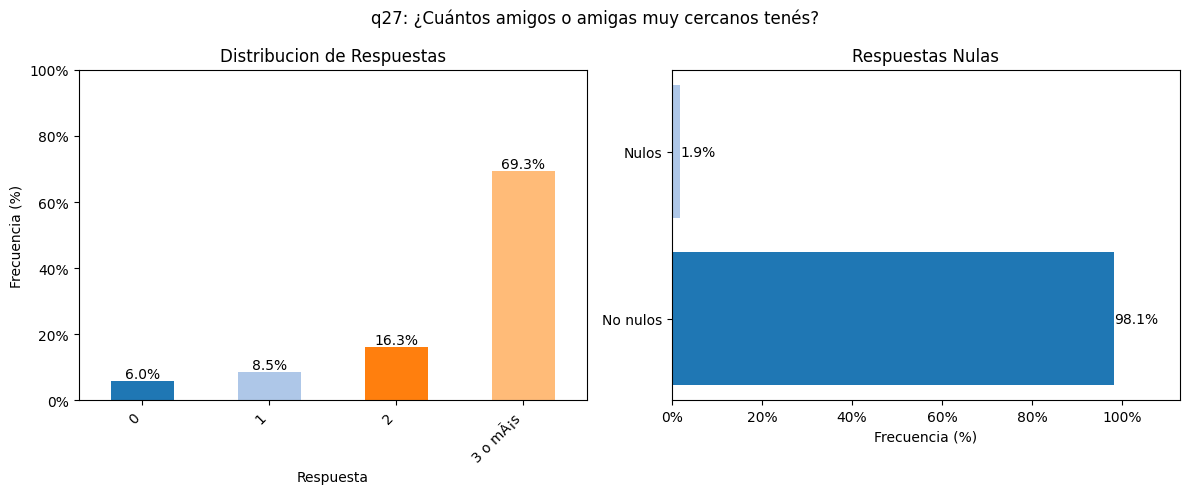

In [12]:
salud_mental = ["q22", "q23", "q24", "q27"]

for q in salud_mental:
    print_question(q)

### 4.4 Violencia y Bullying

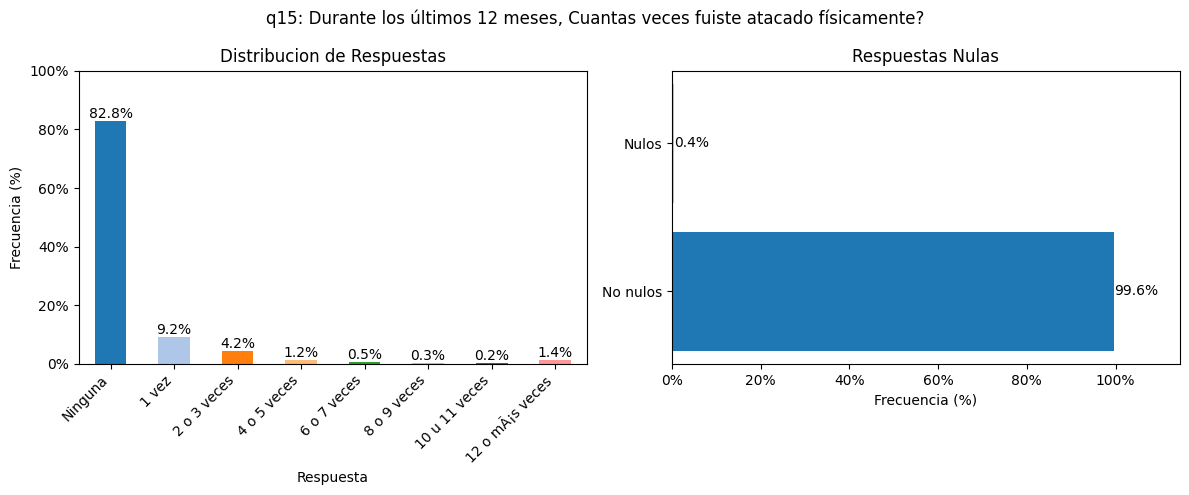

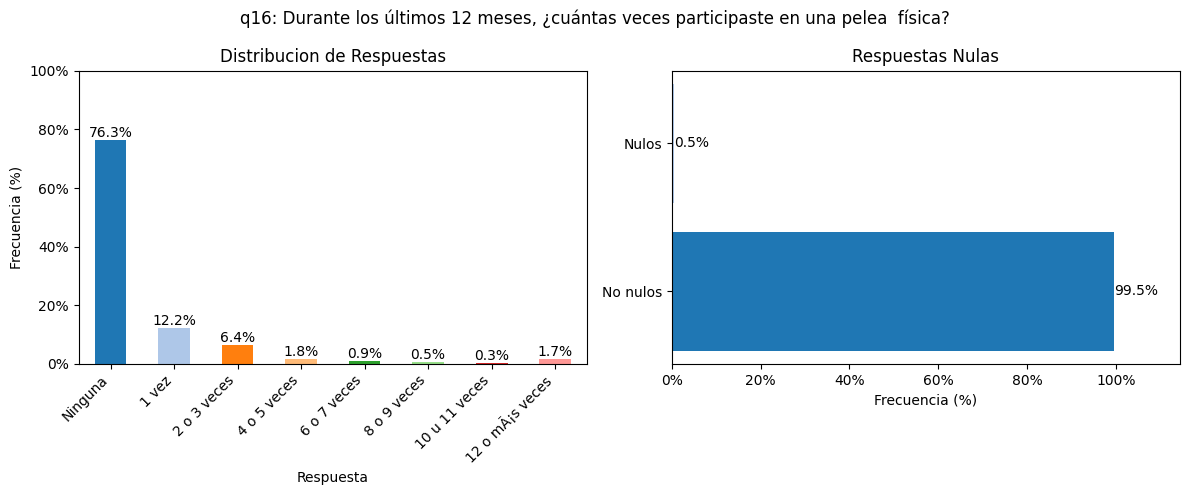

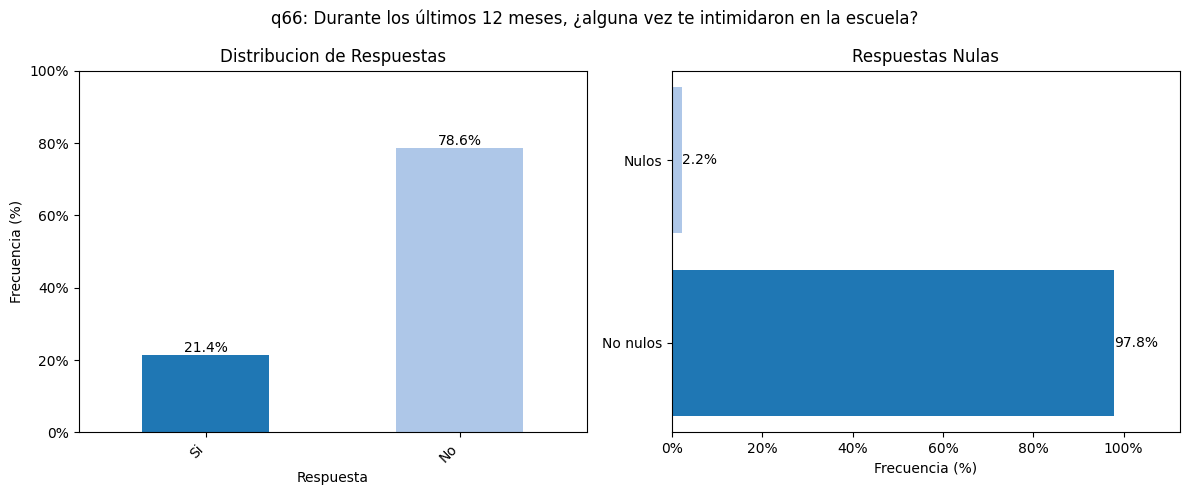

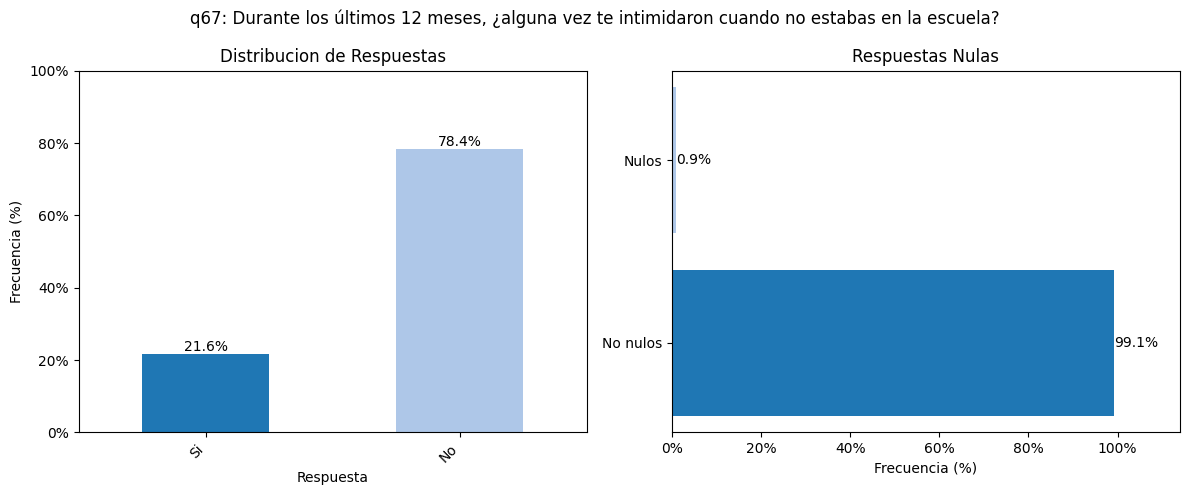

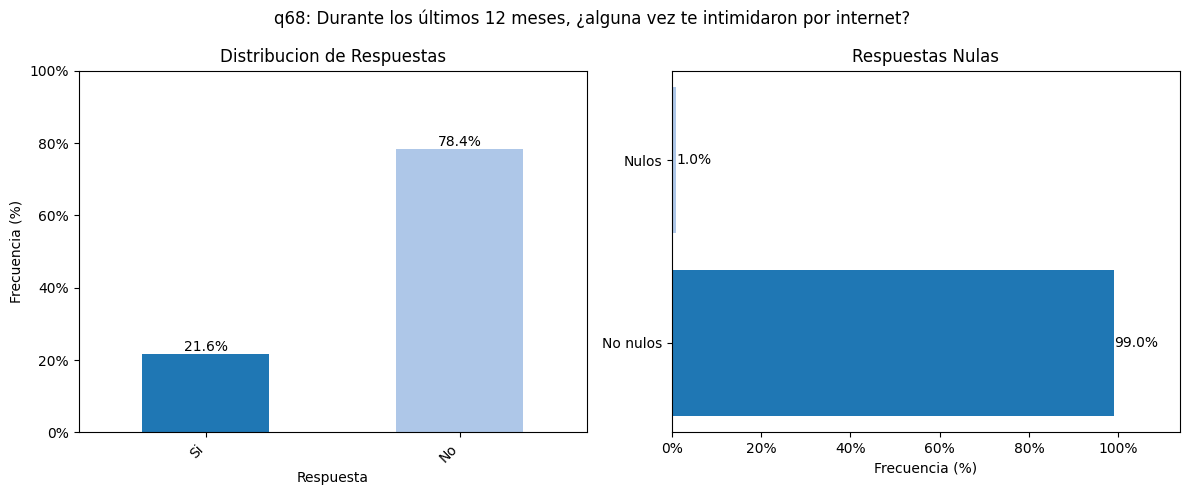

In [13]:
violencia = ["q15", "q16", "q66", "q67", "q68"]

for q in violencia:
    print_question(q)

### 4.5 Apoyo Familiar

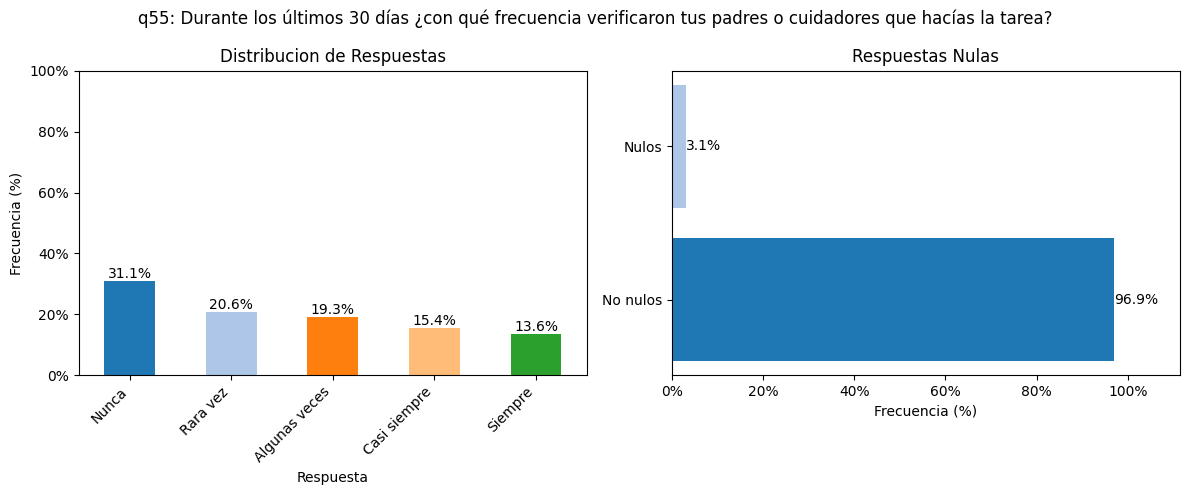

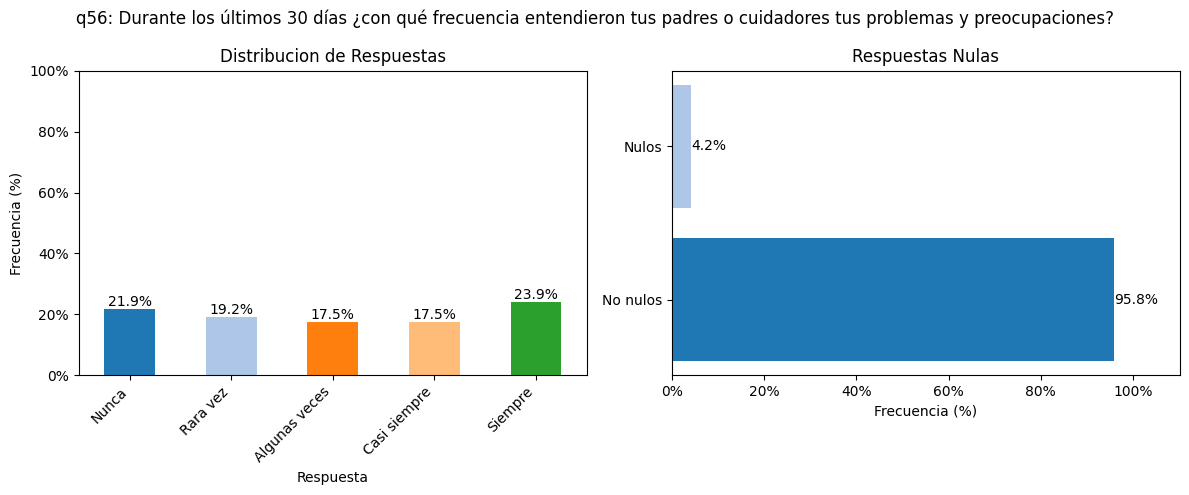

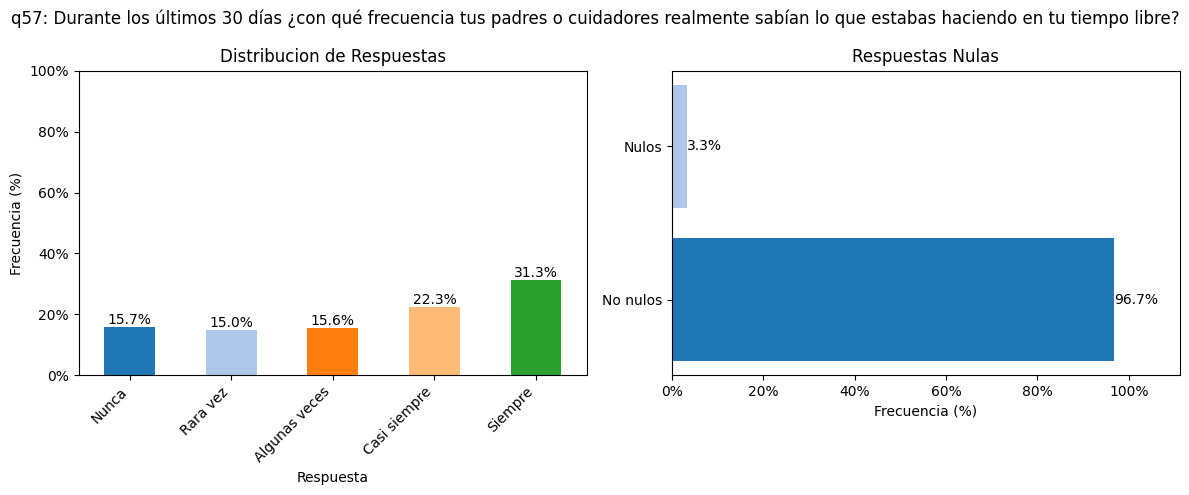

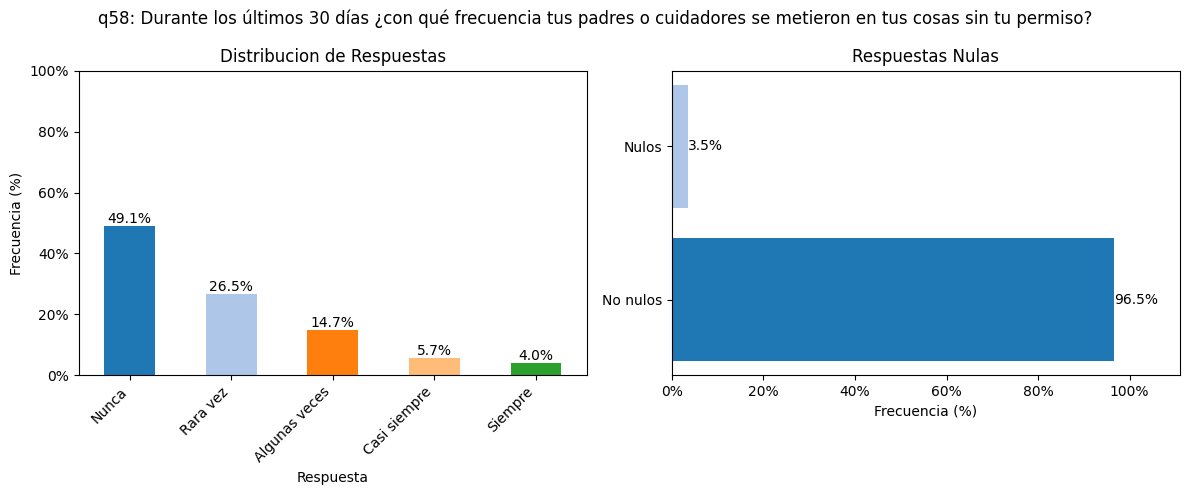

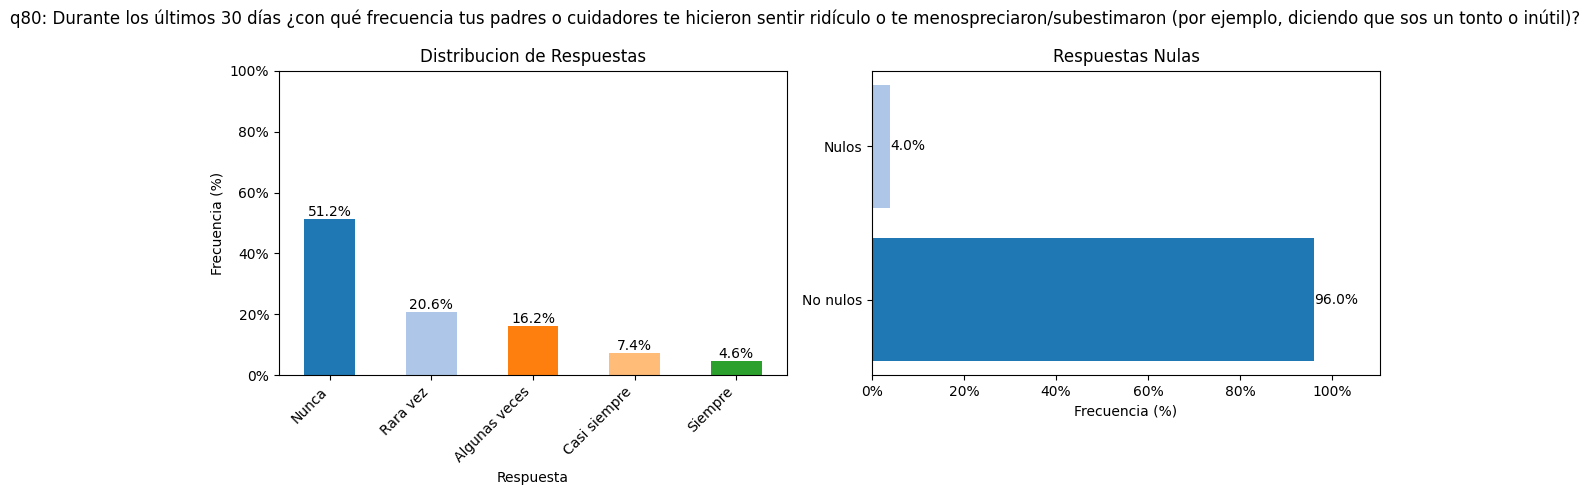

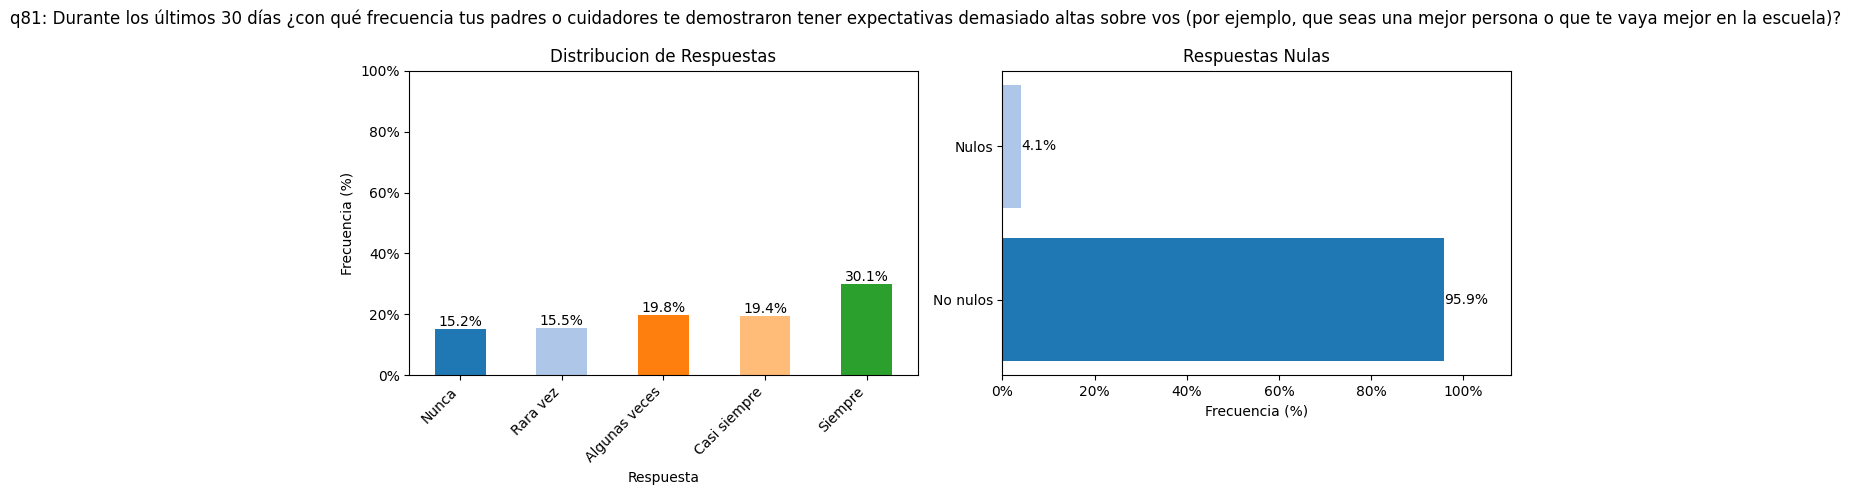

In [14]:
apoyo = ["q55", "q56", "q57", "q58", "q80", "q81"]

for q in apoyo:
    print_question(q)

### 4.6 Consumo de Sustancias

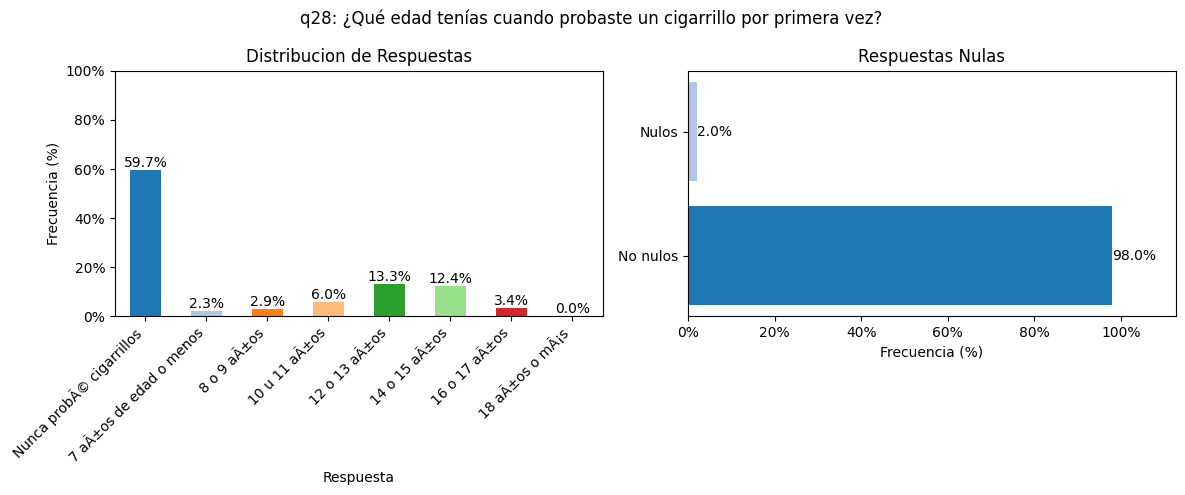

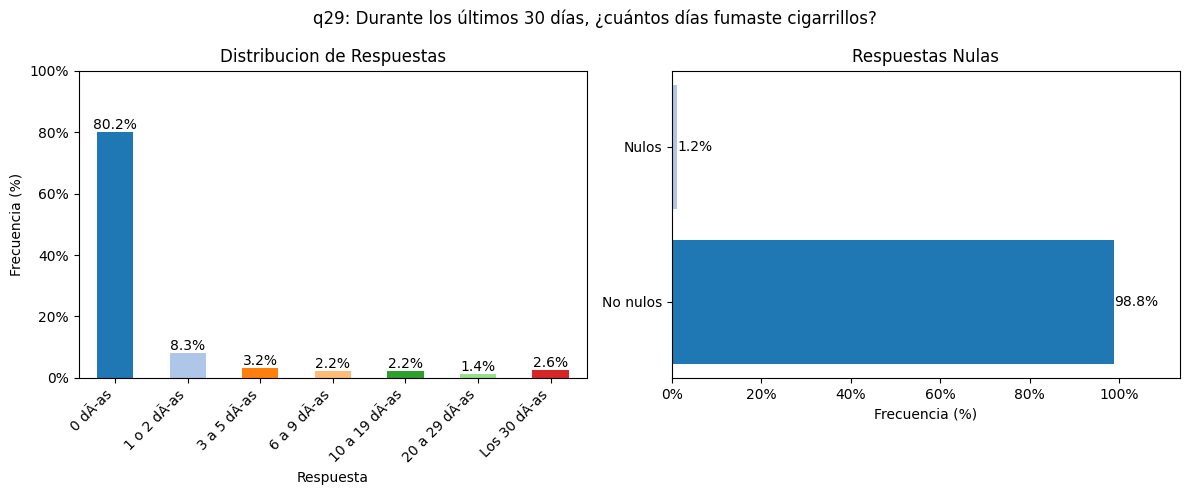

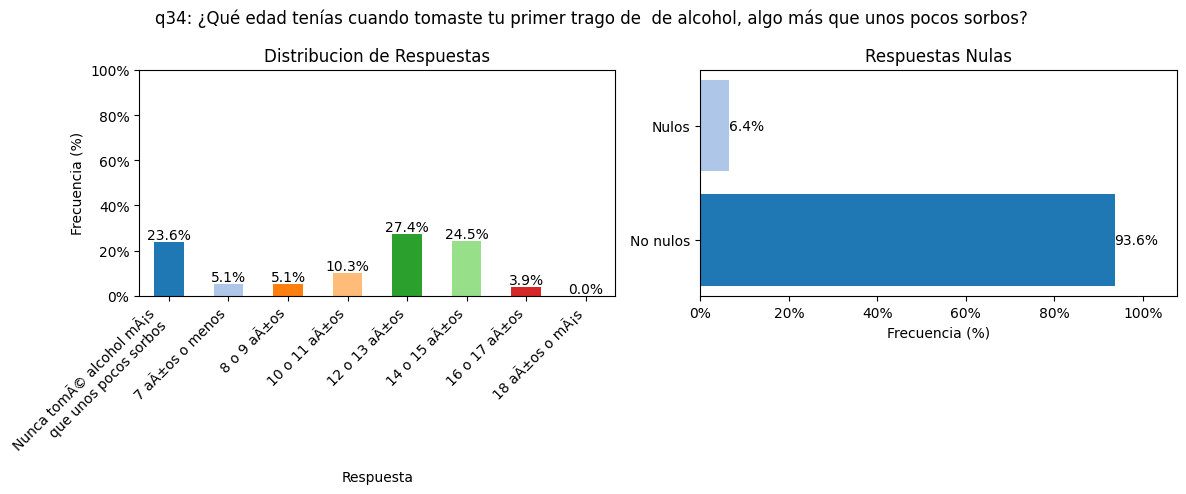

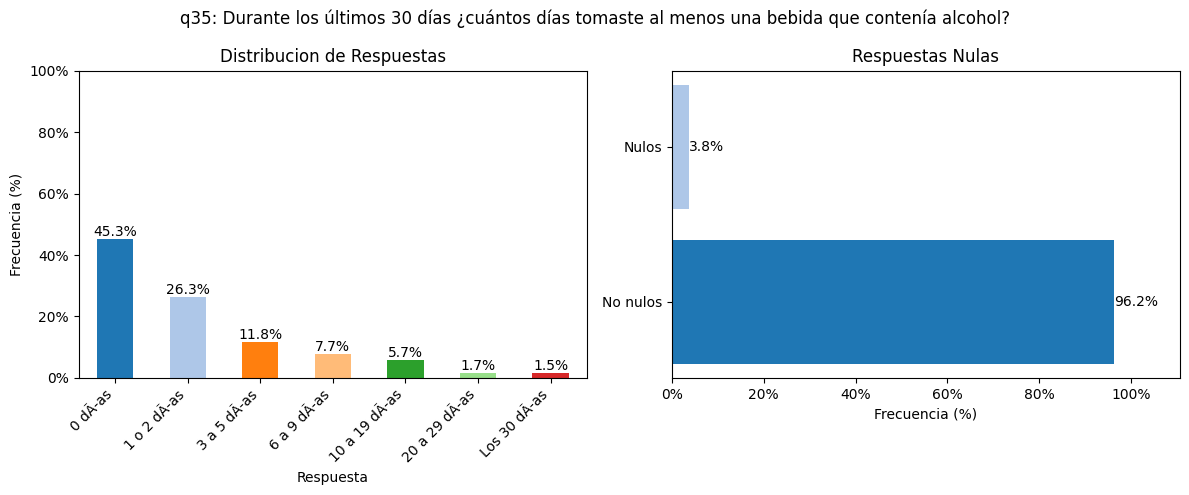

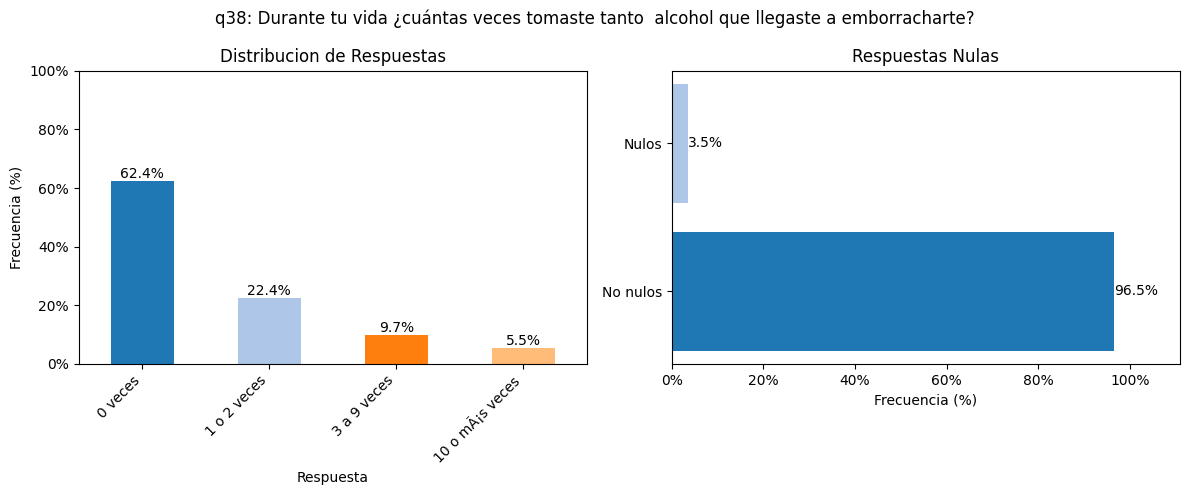

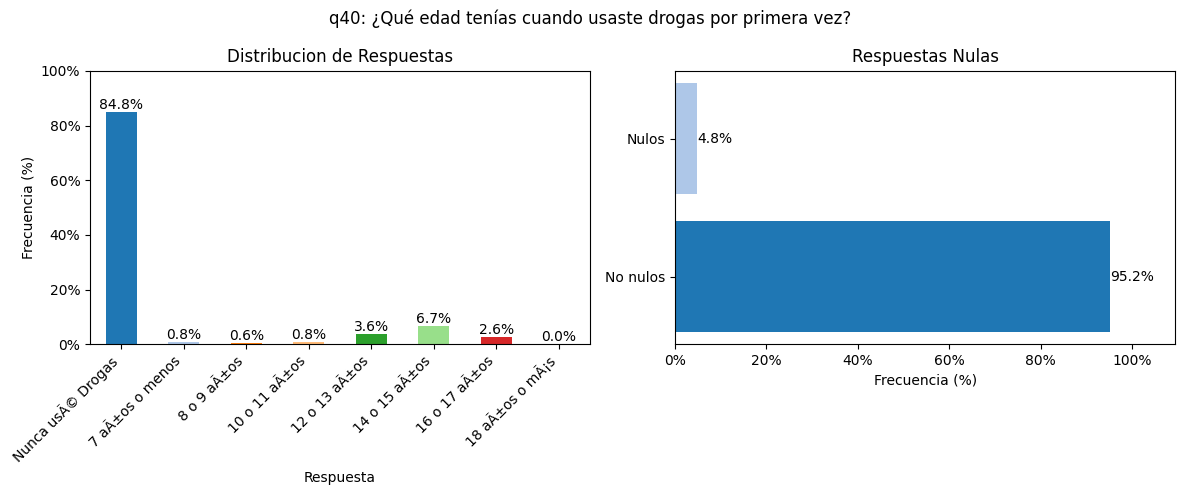

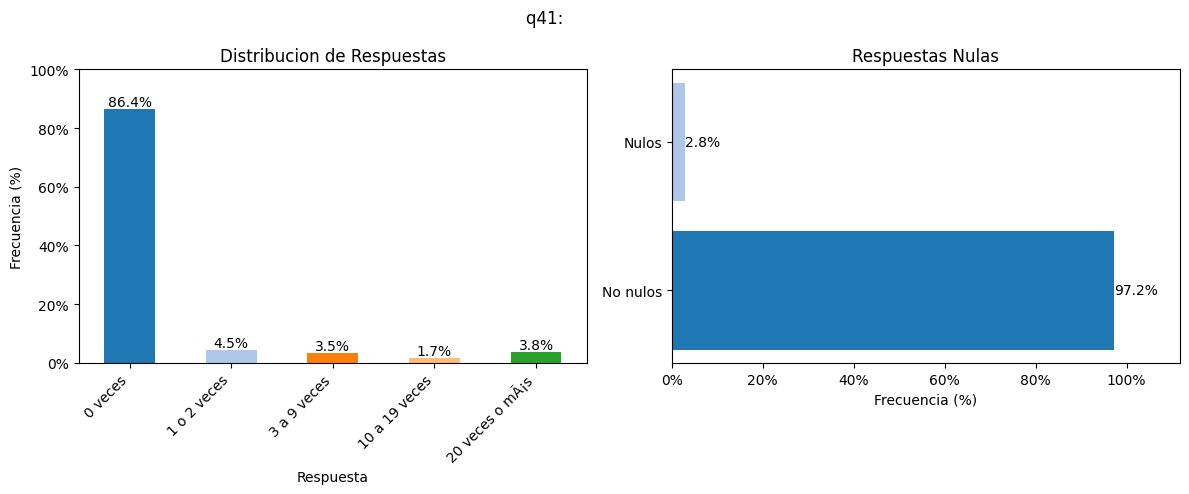

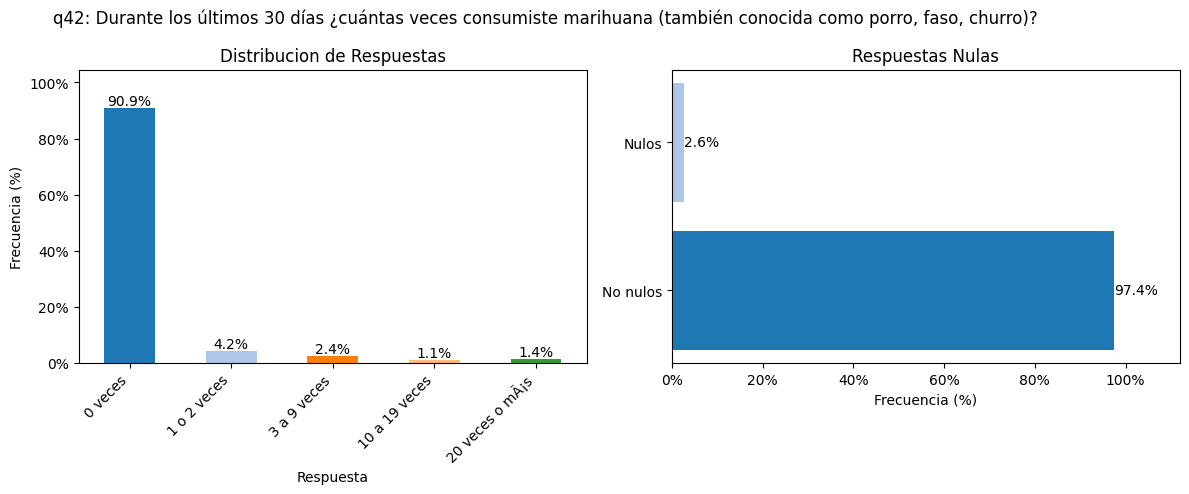

In [15]:
sustancias = ["q28", "q29", "q34", "q35", "q38", "q40", "q41", "q42"]

for q in sustancias:
    print_question(q)

### 4.7 Factores Sociales y Escolares

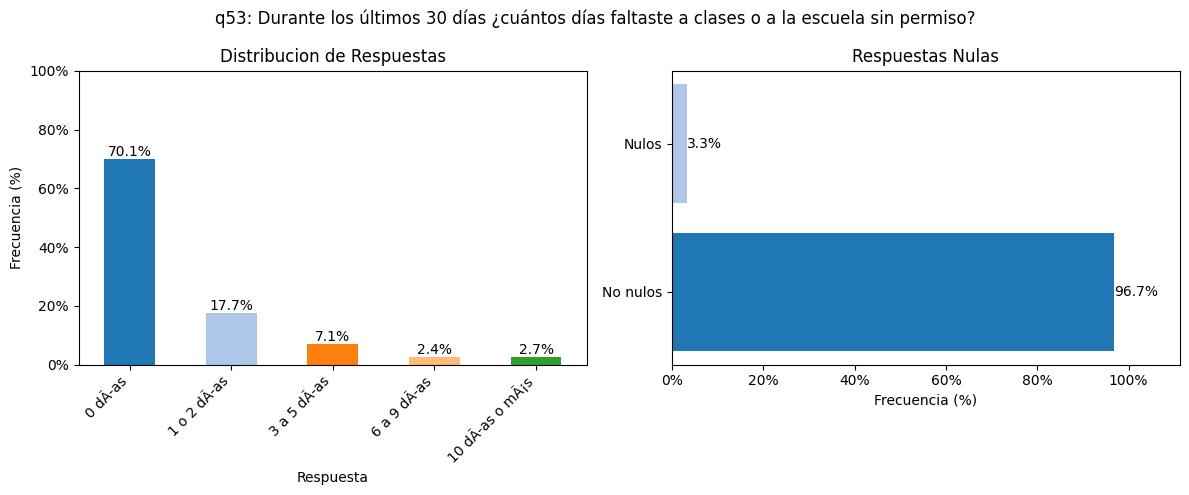

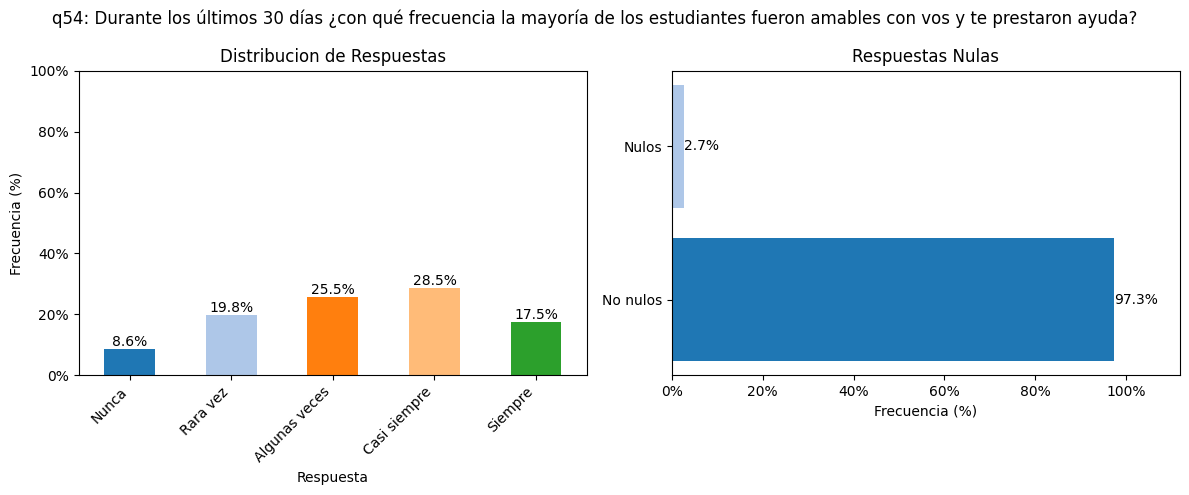

In [16]:
sociales = ["q53", "q54"]

for q in sociales:
    print_question(q)

### 4.8 Factores Socioeconomicos

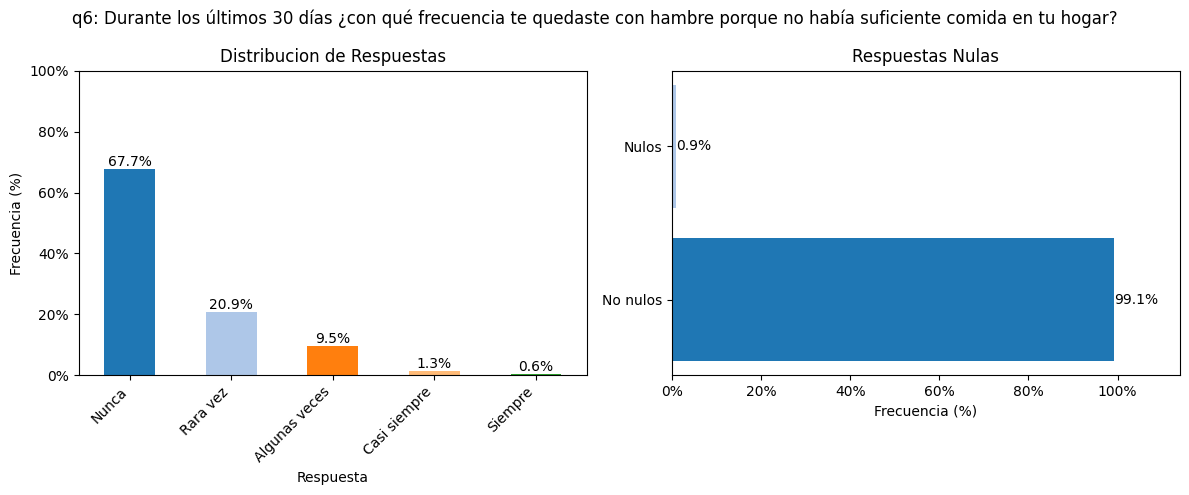

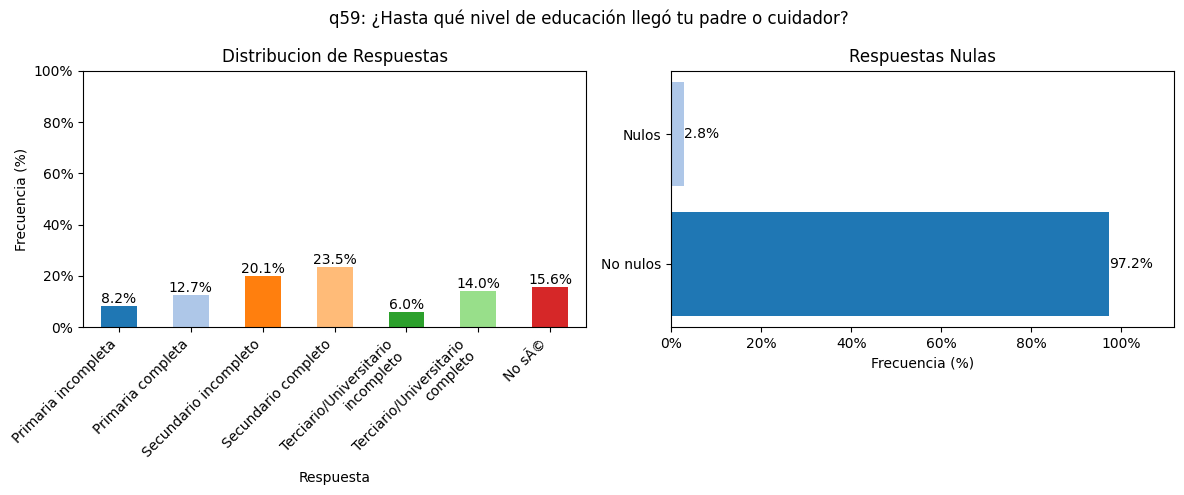

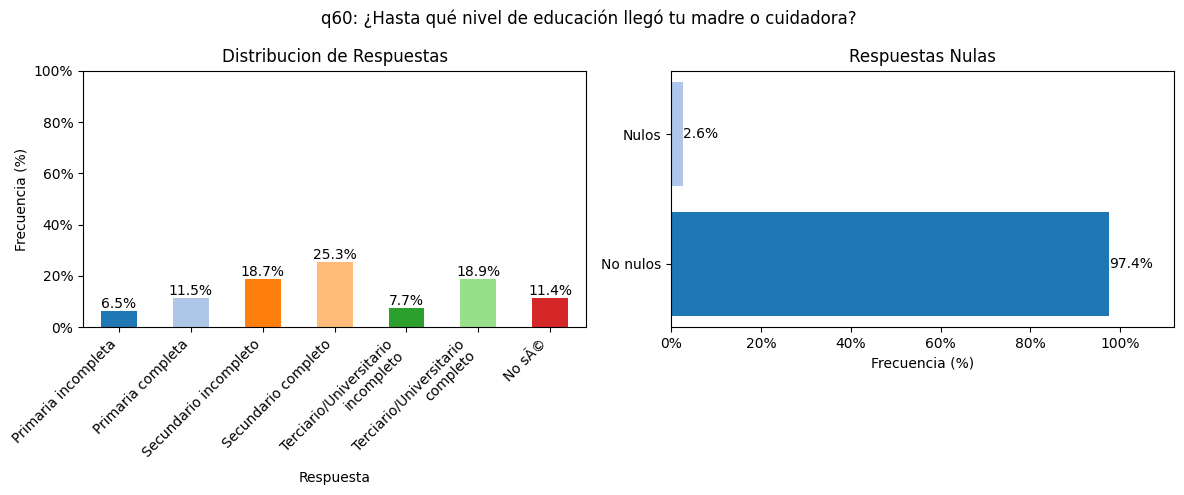

In [17]:
socioeconomicas = ["q6", "q59", "q60"]

for q in socioeconomicas:
    print_question(q)

## 5. Preprocesamiento

Las features que preseleccionamos para nuestro modelo entonces, seran:

In [18]:
features = sum([demograficas, [q for q in salud_mental if q not in ["q25", "q26"]], violencia, apoyo, sustancias, sociales, socioeconomicas, [target]], []) # Usamos sum() para aplanar la lista de listas
print(features)
print(len(features), "features")

['q1', 'q2', 'q3', 'q22', 'q23', 'q24', 'q27', 'q15', 'q16', 'q66', 'q67', 'q68', 'q55', 'q56', 'q57', 'q58', 'q80', 'q81', 'q28', 'q29', 'q34', 'q35', 'q38', 'q40', 'q41', 'q42', 'q53', 'q54', 'q6', 'q59', 'q60', 'En Riesgo']
32 features


In [19]:
data = df[[q for q in features]].copy()
data.head()

,q1,q2,q3,q22,q23,q24,q27,q15,q16,q66,...,q38,q40,q41,q42,q53,q54,q6,q59,q60,En Riesgo
0,3.0,2.0,2.0,5.0,5.0,1.0,3.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,5.0,1.0,2.0,6.0,2.0,0
1,3.0,2.0,2.0,1.0,1.0,2.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,3.0,1.0,3.0,3.0,0
2,4.0,1.0,4.0,1.0,2.0,NaN,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,3.0,1.0,4.0,4.0,0
3,6.0,1.0,2.0,1.0,3.0,2.0,4.0,1.0,3.0,2.0,...,2.0,1.0,1.0,1.0,1.0,3.0,1.0,3.0,3.0,0
4,3.0,2.0,2.0,2.0,3.0,2.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,4.0,1.0,2.0,1.0,0


In [20]:
data.shape

(56981, 32)

## 6. Split del Dataset

Se separa el dataset en entrenamiento (*train*) y evaluacion (*test*) antes de aplicar cualquier transformacion, para evitar el *data leakage*. Las transformaciones que dependen de estadisticos (escalado, balanceo) se calculan unicamente sobre train y luego se aplican a ambos conjuntos, de manera que el test queda como una muestra no vista.

In [21]:
from sklearn.model_selection import train_test_split

Se define la matriz de features `X` y el vector target `y`, y se realiza un split 80/20 con `stratify=y`, que conserva la misma proporcion del target en train y test dado el desbalance de la clase.

Train: 45584 filas | Test: 11397 filas | 31 features


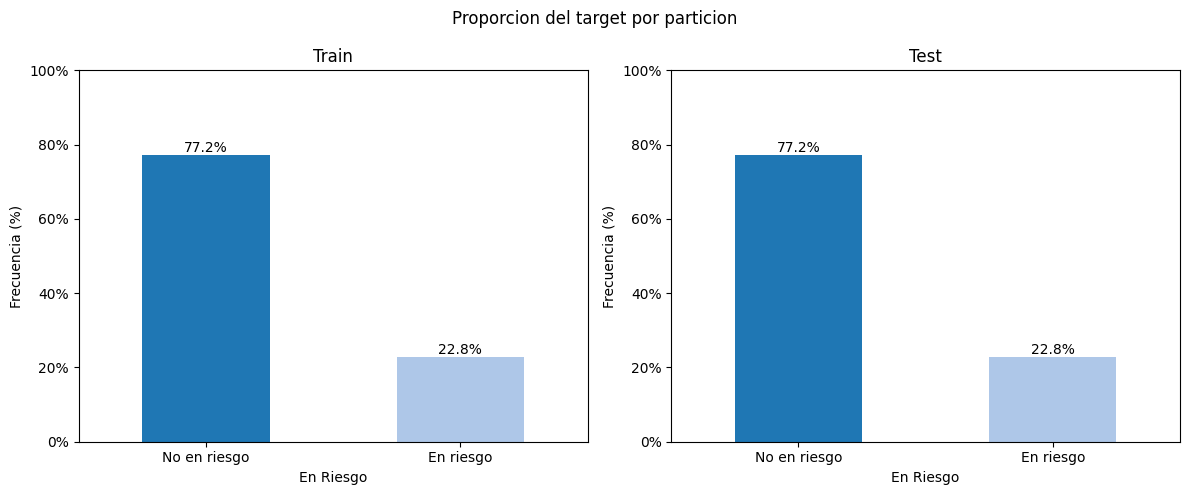

In [22]:
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas | {X_train.shape[1]} features")

# Proporcion del target en cada particion
train_pct = (y_train.value_counts(normalize=True).sort_index() * 100)
test_pct = (y_test.value_counts(normalize=True).sort_index() * 100)
etiquetas = ["No en riesgo", "En riesgo"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Proporcion del target por particion")
colors = get_colors(2)

train_pct.plot(kind="bar", ax=ax1, color=colors)
ax1.set_title("Train")
ax1.set_ylabel("Frecuencia (%)")
ax1.set_xticklabels(etiquetas, rotation=0)
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(PercentFormatter())
for container in ax1.containers:
    ax1.bar_label(container, fmt="%.1f%%")

test_pct.plot(kind="bar", ax=ax2, color=colors)
ax2.set_title("Test")
ax2.set_ylabel("Frecuencia (%)")
ax2.set_xticklabels(etiquetas, rotation=0)
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(PercentFormatter())
for container in ax2.containers:
    ax2.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

## 7. Tratamiento de Nulos

Con el target ya definido (seccion 4.1) y las features preseleccionadas (seccion 5), se tratan los valores faltantes. Se analiza primero la cantidad de nulos por feature sobre el conjunto de **train**.

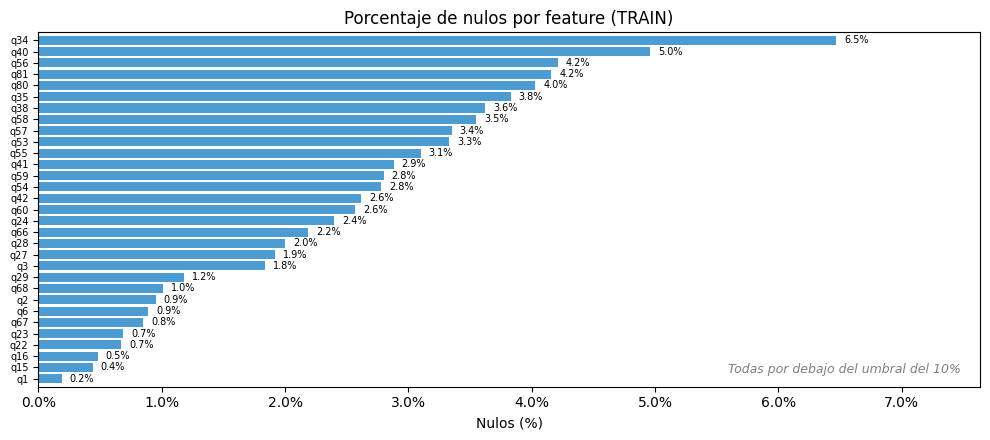

In [23]:
nulos = (X_train.isna().mean() * 100).round(2)
nulos = nulos[nulos > 0].sort_values(ascending=True)

# Porcentaje de nulos por feature. Todas estan muy por debajo del umbral del 10%.
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.barh(nulos.index, nulos.values, color="#4c9bd1")

ax.set_title("Porcentaje de nulos por feature (TRAIN)")
ax.set_xlabel("Nulos (%)")
ax.xaxis.set_major_formatter(PercentFormatter())
ax.set_xlim(0, nulos.max() * 1.18)
ax.tick_params(axis="y", labelsize=7)
ax.margins(y=0.01)

for i, v in enumerate(nulos.values):
    ax.text(v + nulos.max() * 0.01, i, f"{v:.1f}%", va="center", fontsize=7)

# El umbral del 10% queda fuera del rango: todas las features estan por debajo.
ax.text(0.98, 0.04, "Todas por debajo del umbral del 10%",
        transform=ax.transAxes, ha="right", fontsize=9,
        style="italic", color="gray")

plt.tight_layout()
plt.show()

Para detectar si los faltantes responden a un patron, se mide para cada feature **cuanto se correlacionan sus nulos con los de otra feature**. Una barra corta (cercana a 0) indica que la feature falta de forma independiente; una barra larga indica que tiende a quedar vacia junto con otra, lo que delata un patron.

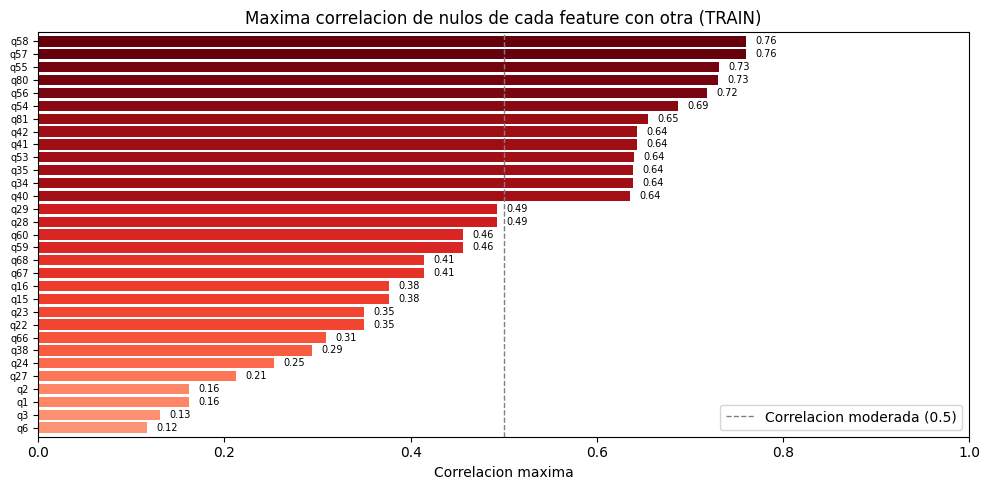

In [24]:
# Para cada feature con nulos, medimos su MAXIMA correlacion de nulo con
# CUALQUIER otra feature (excluyendo la diagonal, que siempre vale 1).
# Una barra larga indica que esa feature tiende a faltar junto con otra.
cols_con_nulos = X_train.columns[X_train.isna().any()]
corr_nulos = X_train[cols_con_nulos].isna().corr()

# Anulamos la diagonal para que no domine el maximo
np.fill_diagonal(corr_nulos.values, np.nan)
max_corr = corr_nulos.max().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Reds(0.25 + 0.75 * max_corr / max_corr.max())
ax.barh(max_corr.index, max_corr.values, color=colors)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="Correlacion moderada (0.5)")
ax.set_title("Maxima correlacion de nulos de cada feature con otra (TRAIN)")
ax.set_xlabel("Correlacion maxima")
ax.set_xlim(0, 1)
ax.tick_params(axis="y", labelsize=7)
ax.margins(y=0.01)
for i, v in enumerate(max_corr.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=7)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

El heatmap revela correlaciones moderadas (hasta ~0.76) entre los nulos de un grupo concreto de features: **q54, q55, q56, q57, q58 y q80**, todas referidas al **apoyo y control parental** ("con que frecuencia tus padres o cuidadores..."). Es decir, los estudiantes que dejaron sin responder una de estas preguntas tendieron a dejar el bloque completo sin responder.

Los faltantes, entonces, no son completamente al azar (MCAR), sino que siguen un patron de **no-respuesta por bloque tematico** (mas cercano a MAR). El resto de las features no muestra correlacion apreciable entre sus nulos.

### 7.1 Eleccion de la estrategia

La estrategia de tratamiento depende de la cantidad de faltantes:

| Cantidad de faltantes | Estrategia |
|---|---|
| **Muy baja (<10%)** | Eliminar filas / Imputar |
| Baja (10-30%) | Imputar (media/mediana/moda segun distribucion) |
| Media (40-60%) | KNN / MICE / otros |
| Alta (70%+) | Eliminar columna completa |

Todas las features tienen un porcentaje de nulos **muy bajo (< 10%)**. El analisis anterior mostro que la mayoria falta de forma independiente, salvo el bloque de apoyo parental, donde la no-respuesta es por patron (MAR). En ambos casos, con un porcentaje tan bajo, las dos estrategias razonables son eliminar filas o imputar.

Aunque para <10% se acepta eliminar filas, ese umbral aplica **por columna**: como hay 31 features, los pequenos porcentajes se acumulan y eliminar toda fila con algun nulo descartaria alrededor del **30% de los registros (unos 16.700 estudiantes)**. Esa perdida es excesiva, sobre todo porque la clase de interes (estudiantes con tendencia suicida) es minoritaria y cada caso aporta senal valiosa.

Por eso se opta por **imputar**. Como las variables son categoricas, se usa la **moda** (`most_frequent`), que conserva el total de registros sin introducir valores intermedios artificiales. A diferencia de eliminar filas, la imputacion calcula un estadistico (la moda), por lo que se ajusta **solo sobre train** y se aplica a train y test, evitando el data leakage.

In [25]:
from sklearn.impute import SimpleImputer

# Imputacion por moda (most_frequent), adecuada para variables categoricas.
# El imputer se ajusta SOLO con train y se aplica a train y test, para no
# filtrar informacion del test (se evita el data leakage).
imputer = SimpleImputer(strategy="most_frequent")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Luego de imputar:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)
print()
print("Nulos restantes en train:", int(X_train.isna().sum().sum()))
print("Nulos restantes en test :", int(X_test.isna().sum().sum()))

Luego de imputar:
X_train: (45584, 31) | y_train: (45584,)
X_test : (11397, 31) | y_test : (11397,)

Nulos restantes en train: 0
Nulos restantes en test : 0


### 7.2 Dataset resultante

Queda definido el dataset: las features preseleccionadas, con los nulos imputados (conservando los 56.981 registros) y con el target ya creado.

In [26]:
total = len(X_train) + len(X_test)
print(f"Registros conservados: {total} de {len(data)} ({total / len(data) * 100:.0f}%)")
print()
X_train.head()

Registros conservados: 56981 de 56981 (100%)



,q1,q2,q3,q22,q23,q24,q27,q15,q16,q66,...,q35,q38,q40,q41,q42,q53,q54,q6,q59,q60
41546,5.0,2.0,5.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,...,5.0,4.0,6.0,5.0,5.0,3.0,4.0,1.0,4.0,3.0
43647,3.0,1.0,1.0,1.0,1.0,2.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,6.0,4.0
37666,3.0,2.0,1.0,1.0,2.0,1.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,5.0,2.0,7.0,7.0
24933,7.0,1.0,4.0,1.0,1.0,2.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,4.0,1.0,4.0,4.0
37928,6.0,2.0,2.0,1.0,4.0,1.0,4.0,2.0,1.0,2.0,...,4.0,2.0,1.0,1.0,1.0,3.0,5.0,1.0,7.0,7.0


## 8. Normalizacion de Features

Las features son categoricas (binarias y ordinales) codificadas como enteros, pero estan en **escalas distintas** (p. ej. q1 -edad- va de 1 a 8, mientras que q24 -binaria- toma valores 1 o 2). Como muchos algoritmos (regresion logistica, KNN, SVM, redes neuronales) y el propio SMOTE se basan en distancias y son sensibles a la escala, se llevan todas las features a un **rango comun [0, 1]** con `MinMaxScaler`.

El scaler se ajusta (`fit`) unicamente sobre train y se aplica (`transform`) a train y test, para no filtrar informacion del test.

Rango global luego de escalar: [0, 1]


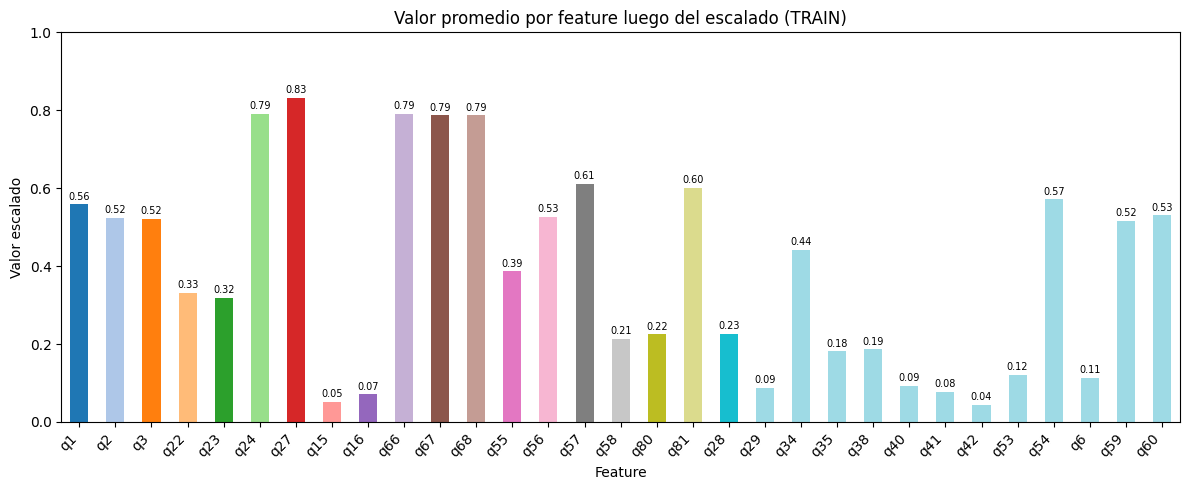

In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit SOLO con train, transform en ambos
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"Rango global luego de escalar: [{X_train_scaled.min().min():.0f}, {X_train_scaled.max().max():.0f}]")

# Valor promedio de cada feature ya escalada (todas dentro de [0, 1])
medias = X_train_scaled.mean()

fig, ax = plt.subplots(figsize=(12, 5))
colors = get_colors(len(medias))
medias.plot(kind="bar", ax=ax, color=colors)
ax.set_title("Valor promedio por feature luego del escalado (TRAIN)")
ax.set_ylabel("Valor escalado")
ax.set_xlabel("Feature")
ax.set_ylim(0, 1)
ax.set_xticklabels(medias.index, rotation=45, ha="right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=7, padding=2)
plt.tight_layout()
plt.show()

Para visualizar el efecto del escalado se compara el rango (minimo a maximo) de cada feature. **Antes**, las barras tienen largos dispares porque cada feature usa una escala propia; **despues**, todas abarcan exactamente el mismo rango [0, 1].

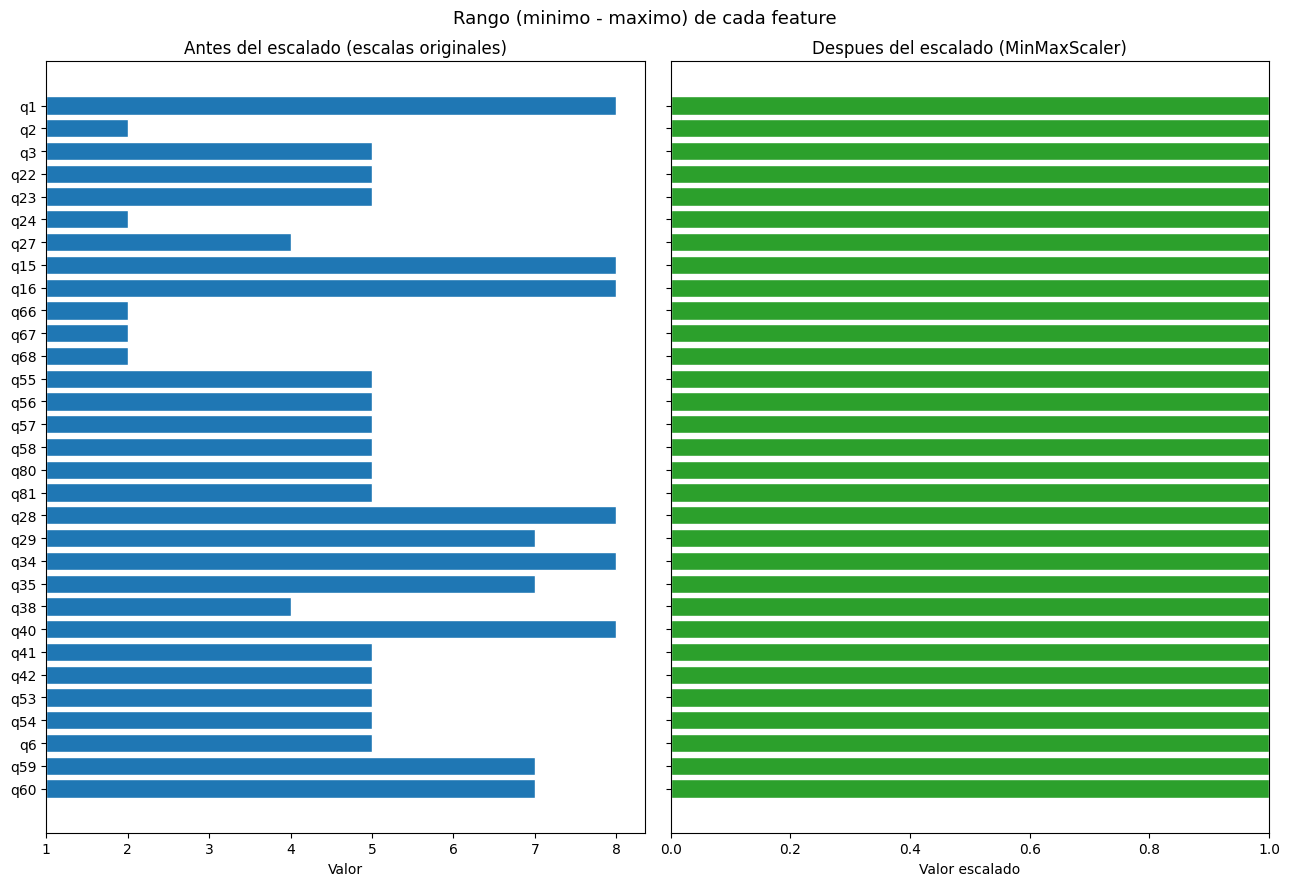

In [28]:
# Rango (minimo - maximo) de cada feature, antes y despues del escalado.
# Cada barra va del valor minimo al maximo de la feature.
feats = X_train.columns[::-1]  # invertimos para que queden en orden de arriba a abajo
y_pos = np.arange(len(feats))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 9), sharey=True)
fig.suptitle("Rango (minimo - maximo) de cada feature", fontsize=13)

# --- Antes del escalado: escalas heterogeneas ---
min_orig = X_train[feats].min()
max_orig = X_train[feats].max()
ax1.barh(y_pos, max_orig - min_orig, left=min_orig,
         color=plt.cm.tab20(0), edgecolor="white")
ax1.set_yticks(y_pos)
ax1.set_yticklabels(feats)
ax1.set_title("Antes del escalado (escalas originales)")
ax1.set_xlabel("Valor")

# --- Despues del escalado: todas en [0, 1] ---
min_sc = X_train_scaled[feats].min()
max_sc = X_train_scaled[feats].max()
ax2.barh(y_pos, max_sc - min_sc, left=min_sc,
         color=plt.cm.tab20(4), edgecolor="white")
ax2.set_title("Despues del escalado (MinMaxScaler)")
ax2.set_xlabel("Valor escalado")
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()

In [29]:
X_train_scaled.head()

,q1,q2,q3,q22,q23,q24,q27,q15,q16,q66,...,q35,q38,q40,q41,q42,q53,q54,q6,q59,q60
41546,0.571429,1.0,1.00,0.25,0.00,1.0,0.333333,0.000000,0.0,1.0,...,0.666667,1.000000,0.714286,1.0,1.0,0.5,0.75,0.00,0.500000,0.333333
43647,0.285714,0.0,0.00,0.00,0.00,1.0,1.000000,0.000000,0.0,1.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.50,0.00,0.833333,0.500000
37666,0.285714,1.0,0.00,0.00,0.25,0.0,1.000000,0.000000,0.0,1.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.00,0.25,1.000000,1.000000
24933,0.857143,0.0,0.75,0.00,0.00,1.0,1.000000,0.000000,0.0,1.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.75,0.00,0.500000,0.500000
37928,0.714286,1.0,0.25,0.00,0.75,0.0,1.000000,0.142857,0.0,1.0,...,0.500000,0.333333,0.000000,0.0,0.0,0.5,1.00,0.00,1.000000,1.000000


## 9. Tratamiento del Desbalance

Se analiza la distribucion del target en el conjunto de **train**.

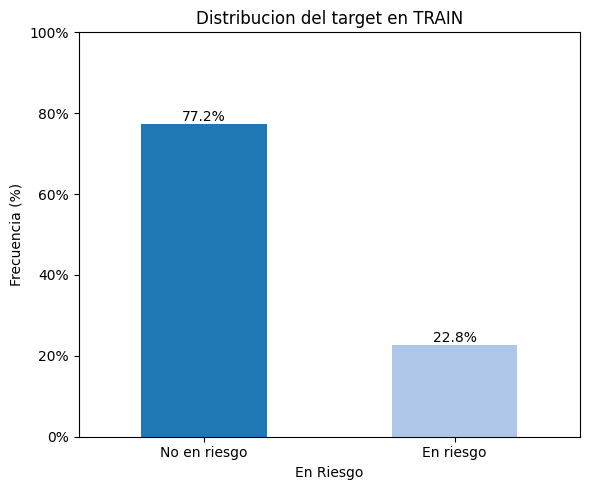

In [30]:
proporcion = (y_train.value_counts(normalize=True).sort_index() * 100)

fig, ax = plt.subplots(figsize=(6, 5))
colors = get_colors(2)
proporcion.plot(kind="bar", ax=ax, color=colors)
ax.set_title("Distribucion del target en TRAIN")
ax.set_ylabel("Frecuencia (%)")
ax.set_xticklabels(["No en riesgo", "En riesgo"], rotation=0)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter())
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.tight_layout()
plt.show()

El target esta **desbalanceado**: cerca del **79%** de los estudiantes corresponde a la clase "No en riesgo" y solo el **21%** a "En riesgo". Sin tratamiento, un modelo tenderia a la clase mayoritaria (prediciendo casi siempre "No en riesgo" con accuracy alta), lo opuesto al objetivo de **detectar** a los estudiantes en riesgo.

### 9.1 Balanceo del target con SMOTE

El balanceo se realiza **en funcion del target** y solo sobre **train**: el test debe conservar la distribucion real para que la evaluacion sea representativa.

Se aplica **SMOTE** (*Synthetic Minority Over-sampling Technique*), que genera ejemplos sinteticos de la clase minoritaria interpolando entre vecinos cercanos en lugar de duplicar filas. Por eso el escalado se aplica antes: SMOTE se basa en distancias.

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("ANTES del balanceo (train):")
print((y_train.value_counts().sort_index()).to_string())
print()
print("DESPUES del balanceo (train):")
print((y_train_bal.value_counts().sort_index()).to_string())
print()
print("X_train_bal:", X_train_bal.shape, "| X_test_scaled (sin balancear):", X_test_scaled.shape)

ANTES del balanceo (train):
En Riesgo
0    35196
1    10388

DESPUES del balanceo (train):
En Riesgo
0    35196
1    35196

X_train_bal: (70392, 31) | X_test_scaled (sin balancear): (11397, 31)


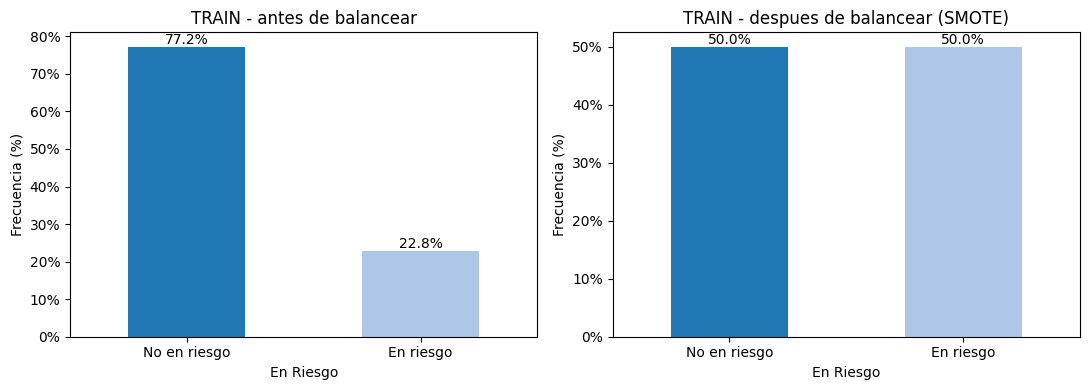

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = get_colors(2)

(y_train.value_counts(normalize=True).sort_index() * 100).plot(
    kind="bar", ax=axes[0], color=colors)
axes[0].set_title("TRAIN - antes de balancear")
axes[0].set_ylabel("Frecuencia (%)")
axes[0].set_xticklabels(["No en riesgo", "En riesgo"], rotation=0)
axes[0].yaxis.set_major_formatter(PercentFormatter())

(y_train_bal.value_counts(normalize=True).sort_index() * 100).plot(
    kind="bar", ax=axes[1], color=colors)
axes[1].set_title("TRAIN - despues de balancear (SMOTE)")
axes[1].set_ylabel("Frecuencia (%)")
axes[1].set_xticklabels(["No en riesgo", "En riesgo"], rotation=0)
axes[1].yaxis.set_major_formatter(PercentFormatter())

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

### 9.2 Consideraciones sobre el desbalanceo

El balanceo se aplica unicamente sobre el **target**, ya que es la variable que el modelo debe predecir. Mas alla del target, varias features presentan categorias poco representadas (respuestas extremas en consumo de sustancias o frecuencias altas de violencia), lo que constituye un desbalanceo a nivel de los predictores. Este no se trata de forma directa: refleja la prevalencia real de cada conducta en la poblacion y forma parte de la senal que el modelo debe aprender, por lo que alterarlo distorsionaria las relaciones entre variables.

Con esto, los conjuntos quedan listos para el modelado:

- **`X_train_bal`, `y_train_bal`** -> entrenamiento (escalado y balanceado).
- **`X_test_scaled`, `y_test`** -> evaluacion (escalado, sin balancear).